# **Treinando um MultiLayer Perceptron**
<font size=3>

Vamos desenvolver um primeiro modelo simples de *deep learning* do tipo **_multilayer perceptron_** (MPL) para uma tarefa de regressão. Aqui, iremos aproveitar nossos estudos prévios de pré-processamento de dados, **modelar** uma *rede neural* e salvar este modelo.


### **_Deep Learning workflow:_**
<font size=3>

Para *modelar* e avaliar corretamente uma rede neural, devemos seguir os seguintes passos de **fluxo de trabalho**:
1. **Importação e análise exploratória dos dados**;
2. **Pré-processamento dos dados**;
3. **Modelagem e compilação do modelo**;
4. **Treinamento validativo**;
5. **Treinamento final**;
6. **Avaliação do modelo**;
7. **Salvar o modelo**.


In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

### **1. Importação e análise exploratória dos dados:**
<font size=3>


Utilizaremos o [_dataset_ de __Consumo de energia na indústria siderúrgica__](https://www.kaggle.com/datasets/csafrit2/steel-industry-energy-consumption) do repositório de dados do **Kaggle**.


In [3]:
# importando os dados:
df = pd.read_csv('/content/drive/MyDrive/IMD3002 - Aprendizado de Máquina Supervisionado/1-unidade/dataset/Steel_industry_data.csv')

# embaralhamento das amostras
df = df.sample(frac=1)

print(df.shape)

df.head()

(35040, 11)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
2994,01/02/2018 04:45,5.11,5.80,0.0,0.00,66.11,100.0,17100,Weekday,Thursday,Light_Load
1442,16/01/2018 00:45,4.64,6.01,0.0,0.00,61.11,100.0,2700,Weekday,Tuesday,Light_Load
18259,10/07/2018 05:00,2.99,4.75,0.0,0.00,53.27,100.0,18000,Weekday,Tuesday,Light_Load
16175,18/06/2018 12:00,71.71,34.85,0.0,0.03,89.94,100.0,43200,Weekday,Monday,Maximum_Load
28058,20/10/2018 06:45,2.84,5.04,0.0,0.00,49.09,100.0,24300,Weekend,Saturday,Light_Load


### **2. Pré-processamento dos dados:**

In [4]:
y = df['CO2(tCO2)'].to_numpy()

X = df[['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
        'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor',
        'Leading_Current_Power_Factor', 'NSM']].to_numpy()

print(f"X: min = {X.min():.2f}, max = {X.max():.2f}, mean = {X.mean():.2f}")
print(f"\ny: min = {y.min():.2f}, max = {y.max():.2f}, mean = {y.mean():.2f}")

X: min = 0.00, max = 85500.00, mean = 7159.87

y: min = 0.00, max = 0.07, mean = 0.01


In [5]:
# dividindo os dados entre trainamento, validação e teste:
N_samples, N_features = X.shape
N_train = int(0.7*N_samples)
N_val = int(0.2*N_samples)

X_train = X[:N_train]
X_val = X[N_train:N_train + N_val]
X_test = X[N_train + N_val:]

print(f"X-tran:{X_train.shape}, X-val:{X_val.shape}, X-test:{X_test.shape}")

y_train = y[:N_train]
y_val = y[N_train:N_train + N_val]
y_test = y[N_train + N_val:]

print(f"y-tran:{y_train.shape}, y-val:{y_val.shape}, y-test:{y_test.shape}")

X-tran:(24528, 6), X-val:(7008, 6), X-test:(3504, 6)
y-tran:(24528,), y-val:(7008,), y-test:(3504,)


In [6]:
# normalização:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [7]:
Max = y_train.max()

y_train /= Max
y_val /= Max
y_test /= Max

print(f"X-train: min = {X_train.min():.2f}, max = {X_train.max():.2f}, mean = {X_train.mean():.2f}")
print(f"y-train: min = {y_train.min():.2f}, max = {y_train.max():.2f}, mean = {y_train.mean():.2f}")

X-train: min = -2.36, max = 5.13, mean = -0.00
y-train: min = 0.00, max = 1.00, mean = 0.16


In [8]:
del df, X, y

### **3. Modelagem e compilação do modelo:**
<font size=3>

Para criar uma **rede neural**, iremos usar a biblioteca [Keras](https://keras.io/guides/functional_api/) um API do *framework* [TensorFlow](https://www.tensorflow.org/learn?hl=pt-br).

In [9]:
from keras import Input, layers, Model

In [10]:
x_in = Input(shape=(N_features,))

x = layers.Dense(32, activation="relu")(x_in)

x = layers.Dense(8, activation="relu")(x)

x_out = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs=x_in, outputs=x_out)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

<font size=3>
<br>
    
Agora, iremos definir o **otimizador**, **função de custo**, e a **métrica** para os dados de validação.

In [11]:
model.compile(optimizer="SGD", loss="mse", metrics=['mae'])

### **4. Treinamento validativo:**
<font size=3>

Este é o momento que validamos a modelagem da rede neural do passo anterior. Verificamos as curvas de **treinamento** e **validação** a fim de identificar se nosso modelo está **bem ajustado**, ou sofre de **_overfitting_** ou **_underfitting_**. Caso a validação não mostre um bom desempenho, devemos voltar ao passo anterior para aprimorar a rede neural — por exemplo, alterando o número de neurônios e camadas (*hiperparâmetros*) — e **reiniciar e executar todo o código**.

In [12]:
final_training = True

n_epochs = 20
batch_saize = 16

if not final_training:

    # treinamento validativo:
    report = model.fit(x=X_train, y=y_train, validation_data=[X_val, y_val],
                       epochs=n_epochs, batch_size=batch_saize)

    # plotando as métricas ao longo das épocas:
    loss = report.history['loss']
    mae = report.history['mae']

    val_loss = report.history['val_loss']
    val_mae = report.history['val_mae']

    epochs = np.linspace(1, len(loss), len(loss))

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    ax[0].plot(epochs, loss, label='MSE')
    ax[0].plot(epochs, val_loss, label='val-MSE')

    ax[1].plot(epochs, mae, label='MAE')
    ax[1].plot(epochs, val_mae, label='val-MAE')

    for i in range(2):
        ax[i].set_xlabel("Epochs")
        ax[i].legend()
        ax[i].grid()

    plt.show()


### **5. Treinamento final:**
<font size=3>

Com a nossa rede bem modelada, agora, faremos o treinamento do modelo final, *juntando* os dados de treinamento e validação.

Epoch 1/20
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0429 - mae: 0.1647
Epoch 2/20
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0127 - mae: 0.0805
Epoch 3/20
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0090 - mae: 0.0619
Epoch 4/20
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0067 - mae: 0.0520
Epoch 5/20
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0048 - mae: 0.0444
Epoch 6/20
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0034 - mae: 0.0380
Epoch 7/20
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0026 - mae: 0.0333
Epoch 8/20
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0022 - mae: 0.0304
Epoch 9/20
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0019 - mae: 0.0287
Epoch 10/20
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0018 - mae: 0.0278
Epoch 11/20
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0017 - mae: 0.0271
Epoch 12/20
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0017 - mae: 0.0265


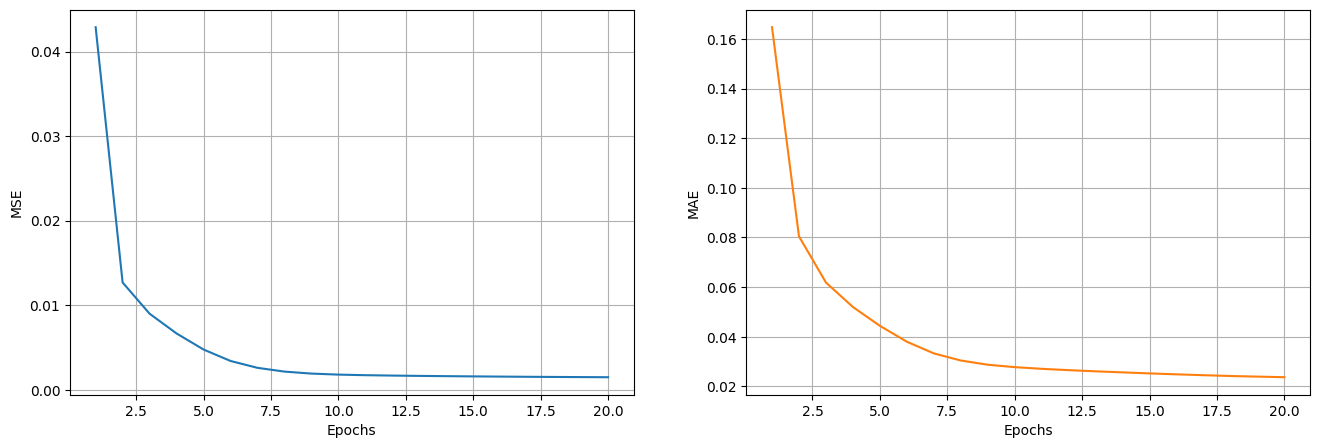

In [13]:
if final_training:

    # treinamento do modelo final:
    report = model.fit(x=np.concatenate([X_train, X_val]),
                       y=np.concatenate([y_train, y_val]),
                       epochs=n_epochs, batch_size=batch_saize)

    # plotando as métricas ao longo das épocas:
    loss = report.history['loss']
    mae = report.history['mae']

    epochs = np.linspace(1, len(loss), len(loss))

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    ax[0].plot(epochs, loss, c='tab:blue')
    ax[1].plot(epochs, mae, c='tab:orange')

    ax[0].set_ylabel('MSE')
    ax[1].set_ylabel('MAE')

    for i in range(2):
        ax[i].set_xlabel("Epochs")
        ax[i].grid()

    plt.show()


### **6. Avaliação do modelo:**
<font size=3>

Avaliando o modelo com os dados de teste.

In [14]:
if final_training:
    mse, mae = model.evaluate(x=X_test, y=y_test, batch_size=batch_saize)

    print(f"\nMSE = {mse:.4f}, MAE = {mae:.4f}\n")


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0014 - mae: 0.0226

MSE = 0.0014, MAE = 0.0226



In [15]:
if final_training:

    y_pred = model.predict(X_test)

    print("\ny-pred | y-test")
    print("---------------")

    for p, y in zip(y_pred[:10], y_test[:10]):

        print(f" {p[0]:.5f}  |  {y:.5f}")


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

y-pred | y-test
---------------
 0.00875  |  0.00000
 0.01397  |  0.00000
 0.00516  |  0.00000
 0.00636  |  0.00000
 0.31942  |  0.28571
 0.01398  |  0.00000
 0.69270  |  0.71429
 0.00675  |  0.00000
 0.11908  |  0.14286
 0.00533  |  0.00000


### **7. Salvar o modelo (_opcional_):**
<font size=3>

Podemos, agora, salvar a arquitetura do modelo em um arquivo $\texttt{.py}$, como uma função ou classe.

<font size=2>
    
```python
def MyModel(input_size=6):
    x_in = Input(shape=(input_size,))
    
    x = layers.Dense(32, activation="relu")(x_in)
    
    x = layers.Dense(8, activation="relu")(x)
    
    x_out = layers.Dense(1, activation="sigmoid")(x)
    
    return Model(inputs=x_in, outputs=x_out)
    
```

<br>


In [23]:
if final_training:
    # salvando os parâmetros (weights, bias) do modelo:
    model.save_weights("/content/drive/MyDrive/IMD3002 - Aprendizado de Máquina Supervisionado/3-unidade/weights/model.weights.h5")

    # salvando (x, y)-test arrays para futuras avaliações:
    np.save("/content/drive/MyDrive/IMD3002 - Aprendizado de Máquina Supervisionado/3-unidade/dataset/x_test.npy", X_test)
    np.save("/content/drive/MyDrive/IMD3002 - Aprendizado de Máquina Supervisionado/3-unidade/dataset/y_test.npy", y_test)


## **Referências:**
<font size=3>
    
 - **(3.4):** F. Chollet, *Deep Learning with Python*. Manning, 2018.
   